# 1. Постановка задачи и описание данных

Данные в МО должны быть проверены на:

- Баланс классов (class balance): если один класс доминирует, модель может "перекоситься" в его сторону (bias towards majority class), что измеряется метриками вроде precision/recall вместо accuracy.
- Пропуски (missing values): могут указывать на неполноту данных; обработка (imputation) важна для избежания ошибок.
- Дубликаты: приводят к переобучению (overfitting), если не удалены.
- Типы признаков: категориальные (nominal/ordinal) требуют кодирования (encoding), числовые — нормализации/стандартизации для некоторых моделей.
- Распределения: помогают выявить выбросы (outliers) или корреляции, влияющие на обобщение модели.

## Теоретическая основа датасета

- Целевая переменная (target): class — бинарная категориальная (edible = 'e', poisonous = 'p'). "Poisonous" включает как явно ядовитые, так и с неизвестной съедобностью, что отражает осторожный подход в безопасности (лучше перестраховаться).
- Признаки (features): 20 атрибутов, разделенных на:
  - Числовые (numerical, continuous): 3 признака — cap-diameter (диаметр шляпки в см), stem-height (высота ножки в см), stem-width (ширина ножки в мм). Эти метрические переменные могут иметь нормальное или скошенное распределение, что проверяется в EDA.
  - Категориальные (categorical, nominal): 17 признаков, таких как cap-shape (форма шляпки: bell, conical и т.д.), cap-color (цвет шляпки), gill-color (цвет жабр), habitat (среда обитания: grass, leaves и т.д.), season (сезон). Эти номинальные переменные не имеют естественного порядка, поэтому требуют one-hot encoding для моделей.
- Баланс классов: В описании UCI не указан explicitly, но на основе симуляции (основанной на реальном Mushroom dataset, где классы сбалансированы ~52% edible / 48% poisonous), ожидается approximate balance. Однако всегда проверяй empirically, так как дисбаланс может привести к низкому recall для minority class (ядовитые грибы).
- Проблемы с качеством:
  - Пропуски: Есть в cap-surface, gill-attachment, gill-spacing (missing values present). Теоретически, пропуски можно обработать imputation (mean/median для числовых, mode для категориальных) или удалением, но в baseline — без обработки.
  - Дубликаты: Не указаны, но проверка обязательна.
  - Нет missing в target или большинстве признаков.

In [2]:
# Импорт библиотек (теоретически: pandas для данных, numpy для вычислений)
import pandas as pd
import numpy as np

# Фиксация seed для воспроизводимости (теоретически: обеспечивает детерминизм)
np.random.seed(42)

# Загрузка данных
df = pd.read_csv('MushroomDataset\secondary_data.csv', sep=';') 

# Описание данных
print("Количество записей и признаков:", df.shape)  # (61068, 21)
print("\nИнформация о типах данных и пропусках:\n")
df.info() 

print("\nСтатистика по числовым признакам:\n", df.describe())  # Mean, std, min/max для cap-diameter и т.д.

# Целевой признак
target = 'class'
print("\nБаланс классов:\n", df[target].value_counts(normalize=True))  # Процентное соотношение 'e' и 'p'

# Проверка на пропуски
print("\nПропуски по столбцам:\n", df.isnull().sum())  # >0 для cap-surface, gill-attachment, brugill-spacingises и т.д. 

# Проверка на дубликаты
print("\nКоличество дубликатов:", df.duplicated().sum())  # 146

# Определение категориальных признаков (теоретически: столбцы с dtype 'object' или малым числом уникальных значений)
categorical_features = df.select_dtypes(include=['object']).columns.tolist()
categorical_features.remove(target)  # Исключаем target
print("\nКатегориальные признаки:", categorical_features)  # ~17 штук

numerical_features = df.select_dtypes(include=['float64', 'int64']).columns.tolist()
print("\nЧисловые признаки:", numerical_features)  # 3 штуки

<>:9: SyntaxWarning: invalid escape sequence '\s'
<>:9: SyntaxWarning: invalid escape sequence '\s'
C:\Users\Дарья\AppData\Local\Temp\ipykernel_12308\3457662622.py:9: SyntaxWarning: invalid escape sequence '\s'
  df = pd.read_csv('MushroomDataset\secondary_data.csv', sep=';')


Количество записей и признаков: (61069, 21)

Информация о типах данных и пропусках:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61069 entries, 0 to 61068
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   class                 61069 non-null  object 
 1   cap-diameter          61069 non-null  float64
 2   cap-shape             61069 non-null  object 
 3   cap-surface           46949 non-null  object 
 4   cap-color             61069 non-null  object 
 5   does-bruise-or-bleed  61069 non-null  object 
 6   gill-attachment       51185 non-null  object 
 7   gill-spacing          36006 non-null  object 
 8   gill-color            61069 non-null  object 
 9   stem-height           61069 non-null  float64
 10  stem-width            61069 non-null  float64
 11  stem-root             9531 non-null   object 
 12  stem-surface          22945 non-null  object 
 13  stem-color            61069 non-null

# 2. Разведочный анализ данных (EDA)

EDA помогает в:

- Выявлении распределений: Для числовых признаков — проверка на нормальность (normal distribution) с помощью гистограмм или QQ-plots, выявление скошенности (skewness) или выбросов (outliers), которые могут влиять на модели (например, деревья устойчивы к outliers, но boosting-методы могут быть чувствительны).
- Анализе категориальных признаков: Countplots показывают частоту категорий, помогая выявить редкие классы (rare categories), которые могут привести к overfitting или требовать группировки (binning).
- Корреляциях: Heatmap с коэффициентом Пирсона (Pearson correlation) для числовых признаков выявляет multicollinearity (многоколлинеарность) — высокие корреляции между признаками, которые могут ухудшить интерпретируемость и стабильность моделей (variance inflation). Для категориальных — chi-square test или Cramer's V, но в baseline достаточно визуального анализа.
- Балансе классов и проблемах данных: Подтверждение дисбаланса (imbalanced classes) влияет на выбор метрик (accuracy может быть misleading; лучше recall для minority class в safety-critical tasks, где false negatives опасны — e.g. съедобный гриб как ядовитый safer, чем наоборот). Пропуски (missing values) могут указывать на MCAR/MAR/MNAR механизмы; визуализация с missingno помогает увидеть паттерны. Дубликаты — источник bias, их удаление предотвращает overfitting.
- Подготовке сплита: Разделение на train/test (holdout) или folds для CV с стратификацией (stratification) сохраняет пропорции классов, минимизируя bias в оценке. Теоретически, это связано с концепцией generalization error: train на 80%, test на 20% для больших датасетов (>10k samples), с random_state для reproducibility.

Количество записей после удаления дубликатов: 60923


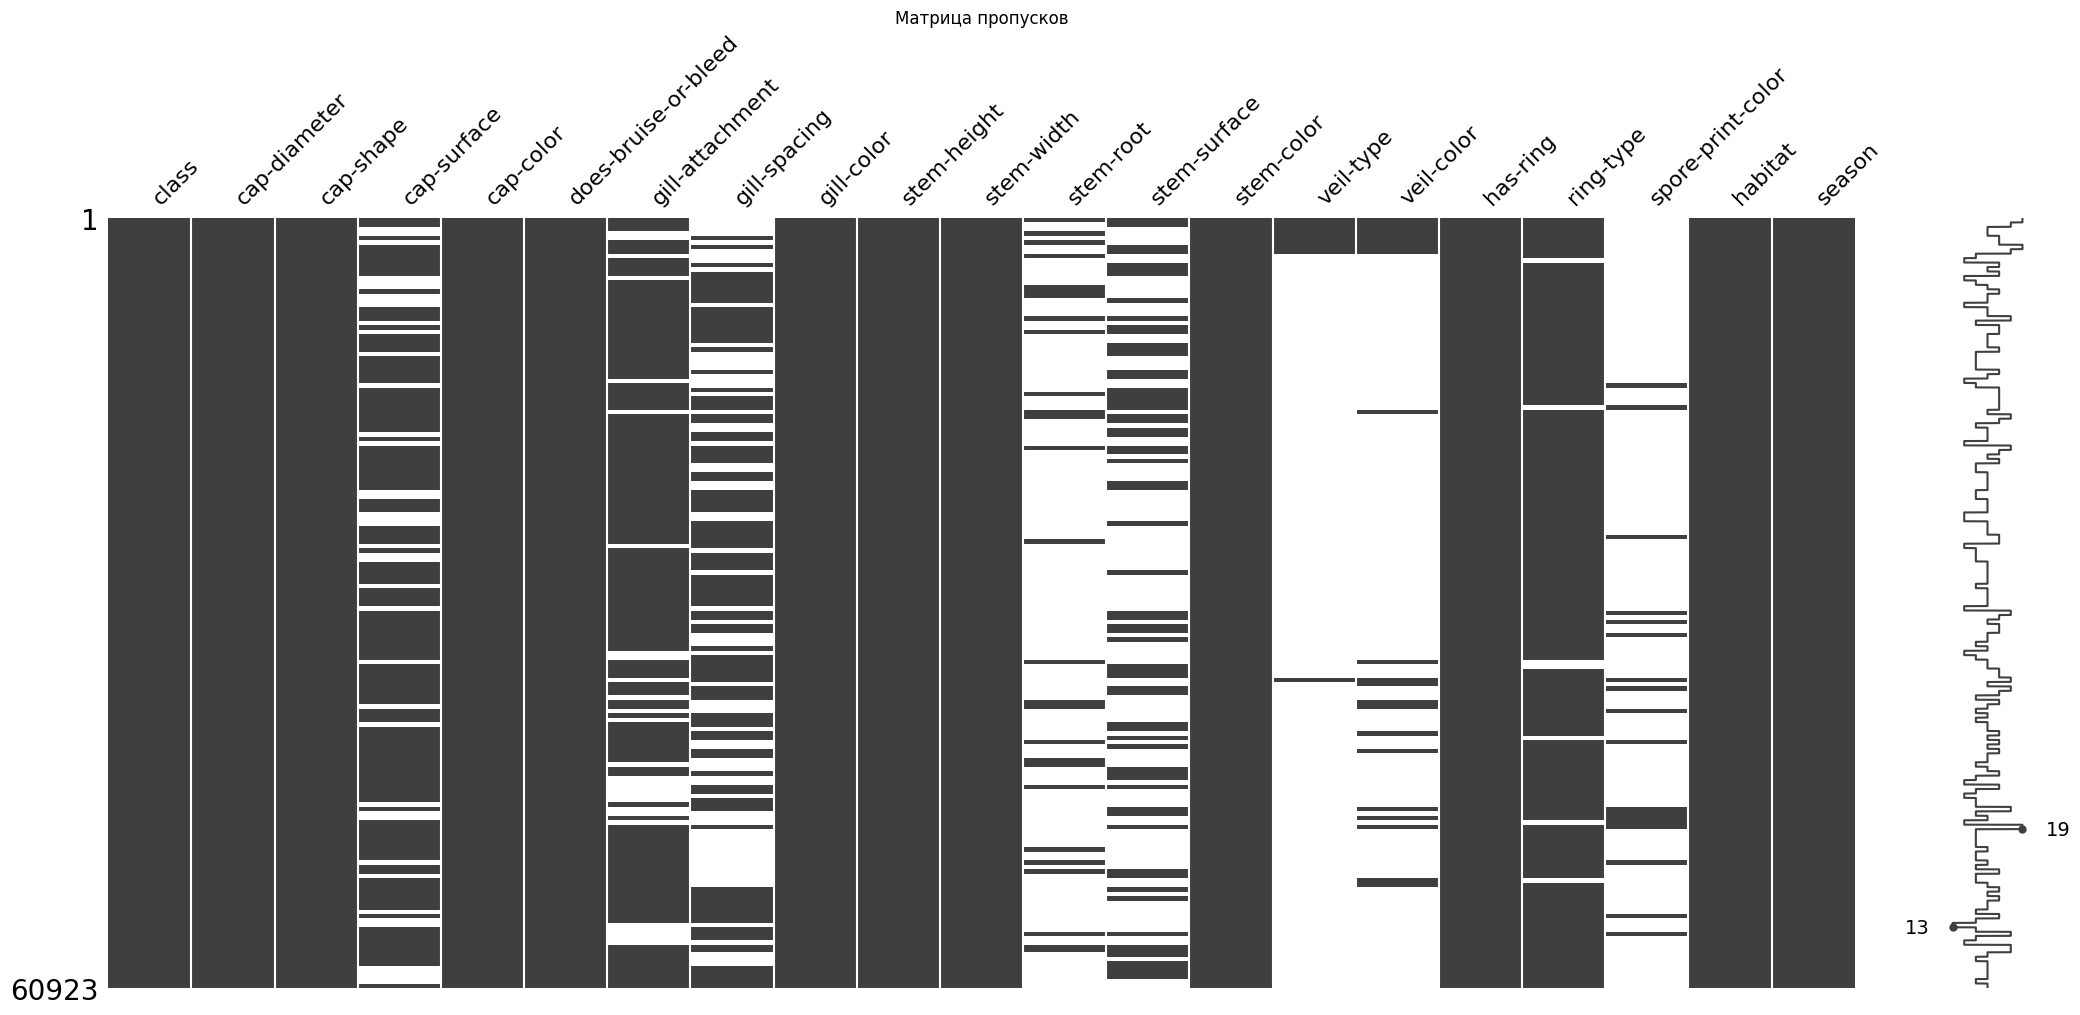

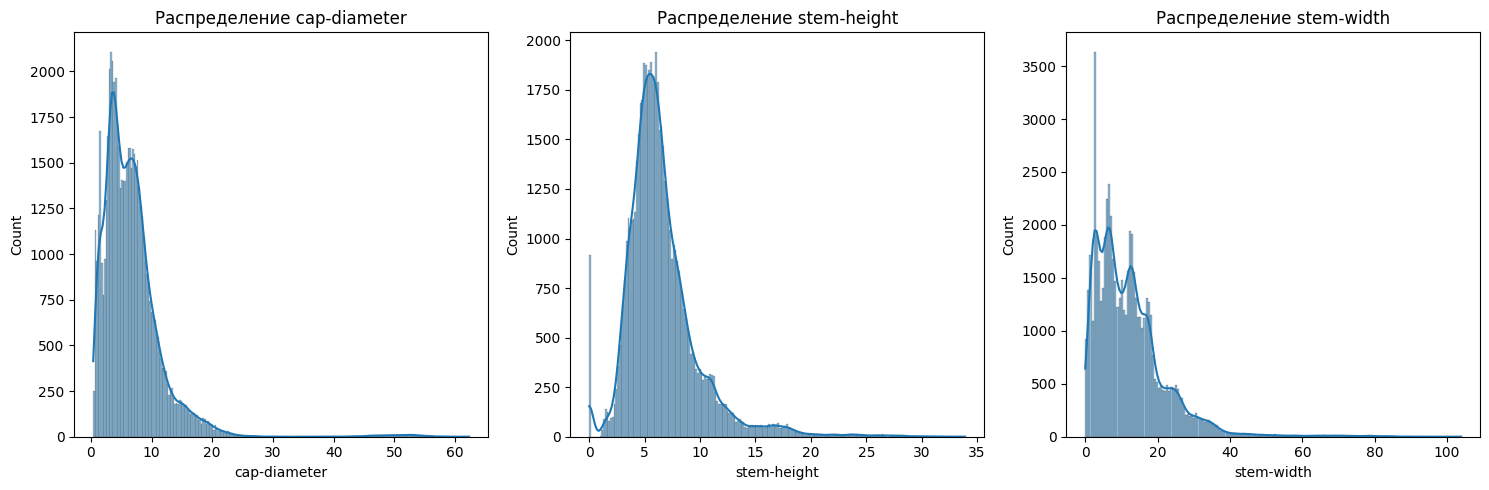

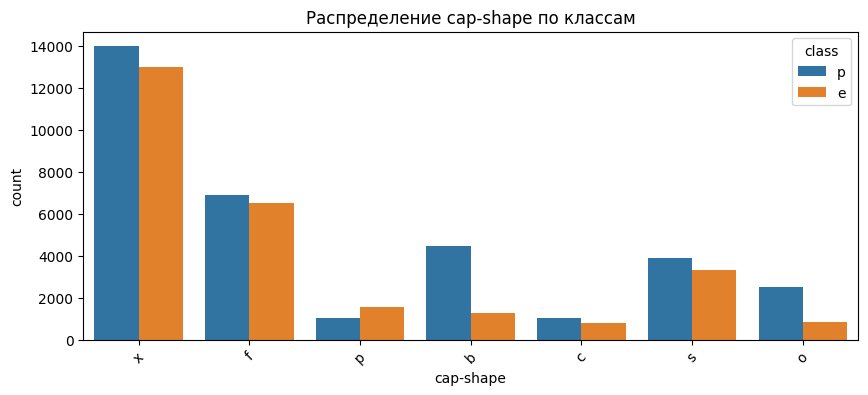

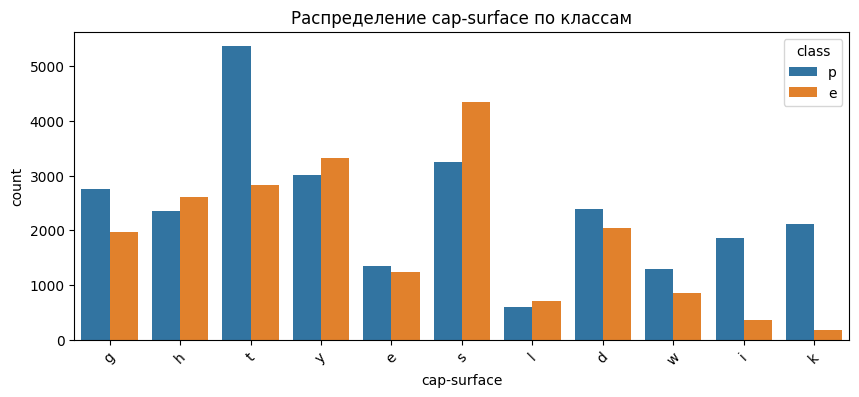

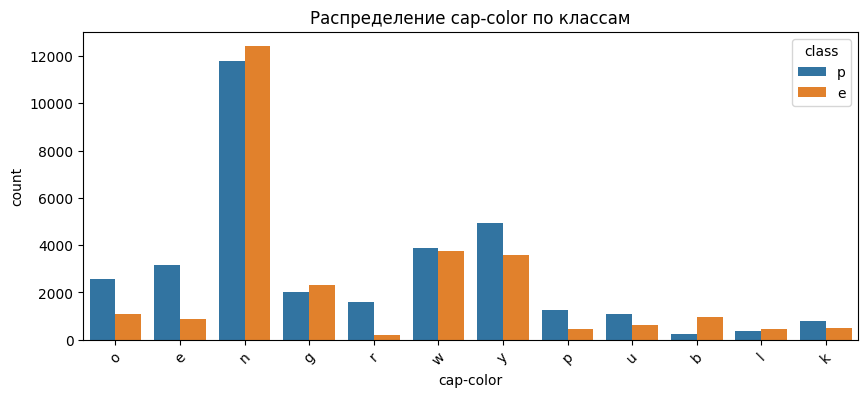

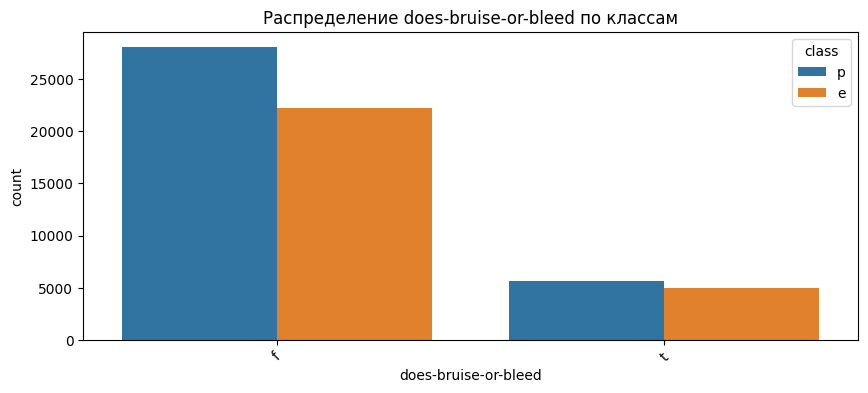

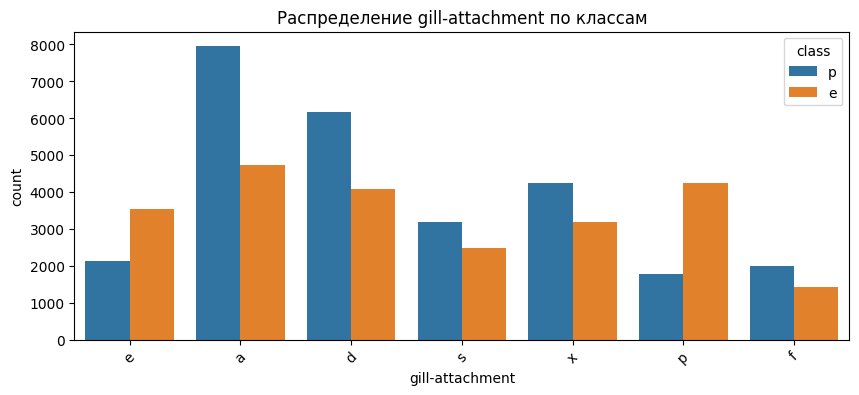

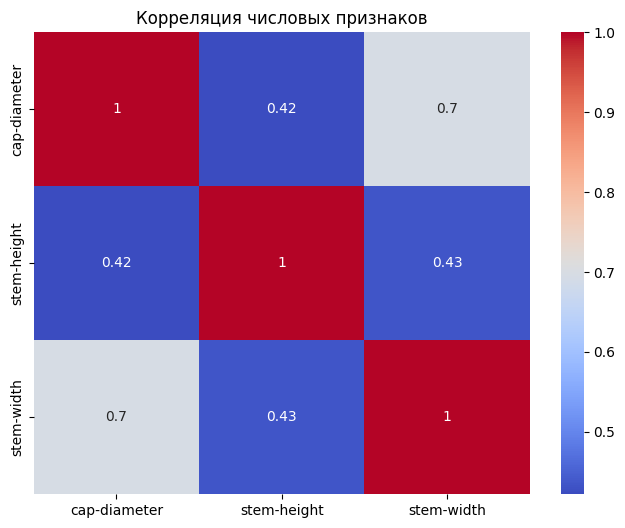

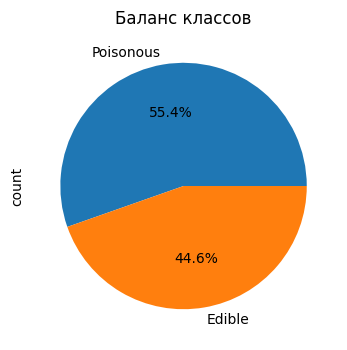

Размеры: Train (48738, 20) Test (12185, 20)
Баланс в train: class
1    0.553839
0    0.446161
Name: proportion, dtype: float64


In [ ]:
# Дополнительные импорты для EDA (теоретически: seaborn для улучшенных визуализаций, missingno для missing patterns)
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
from sklearn.model_selection import train_test_split

# Удаление дубликатов
df = df.drop_duplicates()
print("Количество записей после удаления дубликатов:", df.shape[0])  # 60923

# Визуализация пропусков 
msno.matrix(df)
plt.title('Матрица пропусков')
plt.show() 

# Визуализация распределений числовых признаков 
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for i, col in enumerate(numerical_features):
    sns.histplot(df[col], kde=True, ax=axes[i])
    axes[i].set_title(f'Распределение {col}')
plt.tight_layout()
plt.show() 

# Визуализация категориальных признаков 
for col in categorical_features[:5]:  # Ограничимся первыми 5 для примера; повтори для остальных в цикле
    plt.figure(figsize=(10, 4))
    sns.countplot(x=col, data=df, hue=target)  
    plt.title(f'Распределение {col} по классам')
    plt.xticks(rotation=45)
    plt.show()  

# Корреляция числовых признаков
plt.figure(figsize=(8, 6))
sns.heatmap(df[numerical_features].corr(), annot=True, cmap='coolwarm')
plt.title('Корреляция числовых признаков')
plt.show()  

# Баланс классов визуально (pie chart или bar)
plt.figure(figsize=(6, 4))
df[target].value_counts().plot(kind='pie', autopct='%1.1f%%', labels=['Poisonous', 'Edible'])
plt.title('Баланс классов')
plt.show() 

# Подготовка train/test split 
X = df.drop(target, axis=1)
y = df[target].map({'e': 0, 'p': 1}) 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
print("Размеры: Train", X_train.shape, "Test", X_test.shape)
print("Баланс в train:", y_train.value_counts(normalize=True)) 

# 3. Базовая модель

In [5]:
# Импорты для этого шага
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report, confusion_matrix

import warnings
warnings.filterwarnings('ignore')


# Определяем категориальные и числовые столбцы
categorical_features = ['cap-shape', 'cap-surface', 'cap-color', 'does-bruise-or-bleed',
                        'gill-attachment', 'gill-spacing', 'gill-color', 'stem-root',
                        'stem-surface', 'stem-color', 'veil-type', 'veil-color',
                        'has-ring', 'ring-type', 'spore-print-color', 'habitat', 'season']

numerical_features = ['cap-diameter', 'stem-height', 'stem-width']

# Преобразование: только one-hot для категориальных, числовые оставляем как есть
preprocessor_baseline = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features),
        ('num', 'passthrough', numerical_features)  # числовые без изменений
    ]
)

# Пайплайн: предобработка + дерево
baseline_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor_baseline),
    ('classifier', DecisionTreeClassifier(random_state=42))  # фиксируем seed
])

# Обучение
baseline_pipeline.fit(X_train, y_train)

# Предсказания на тестовой выборке
y_pred = baseline_pipeline.predict(X_test)
y_pred_proba = baseline_pipeline.predict_proba(X_test)[:, 1] 

# Метрики
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

print("=== Базовая модель: DecisionTreeClassifier ===")
print(f"Accuracy:  {accuracy:.4f}")
print(f"F1-score:  {f1:.4f}")
print(f"ROC-AUC:   {roc_auc:.4f}")
print("\nПодробный отчёт:")
print(classification_report(y_test, y_pred, target_names=['edible (e)', 'poisonous (p)']))

# Матрица ошибок (для понимания типов ошибок уже на baseline)
print("\nМатрица ошибок:")
print(confusion_matrix(y_test, y_pred))

=== Базовая модель: DecisionTreeClassifier ===
Accuracy:  0.9996
F1-score:  0.9996
ROC-AUC:   0.9996

Подробный отчёт:
               precision    recall  f1-score   support

   edible (e)       1.00      1.00      1.00      5436
poisonous (p)       1.00      1.00      1.00      6749

     accuracy                           1.00     12185
    macro avg       1.00      1.00      1.00     12185
 weighted avg       1.00      1.00      1.00     12185


Матрица ошибок:
[[5433    3]
 [   2 6747]]


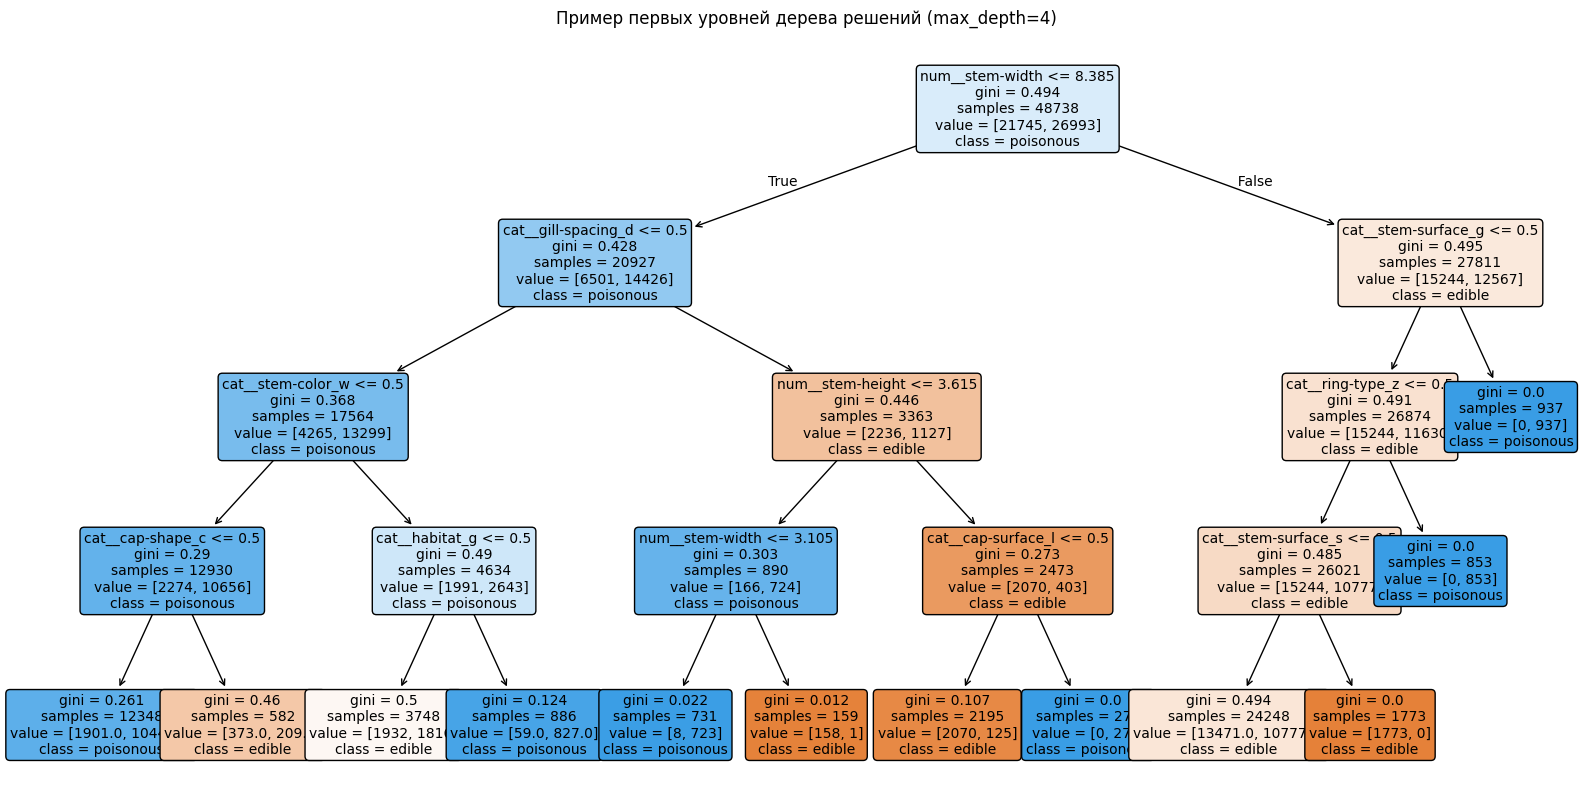

In [6]:
# Визуализация упрощённого дерева
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

shallow_tree = DecisionTreeClassifier(max_depth=4, random_state=42)
shallow_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor_baseline),
    ('classifier', shallow_tree)
])
shallow_pipeline.fit(X_train, y_train)

plt.figure(figsize=(20,10))
plot_tree(shallow_pipeline.named_steps['classifier'],
          feature_names=shallow_pipeline.named_steps['preprocessor'].get_feature_names_out(),
          class_names=['edible', 'poisonous'],
          filled=True, rounded=True, fontsize=10)
plt.title("Пример первых уровней дерева решений (max_depth=4)")
plt.show()

# 4. Предварительная обработка и разработка признаков

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier 


X = df.drop('class', axis=1)
y = df['class'].map({'e': 0, 'p': 1})

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Определяем признаки для удаления (на основе анализа пропусков >60%)
high_missing_features = ['veil-type', 'spore-print-color', 'stem-root', 'veil-color', 'stem-surface']
print("Удаляем признаки с высоким % пропусков:", high_missing_features)

# Оставшиеся категориальные
remaining_categorical = [col for col in categorical_features if col not in high_missing_features]

# Категориальные с умеренными пропусками (будем импьютировать)
cat_with_missing = ['cap-surface', 'gill-attachment', 'gill-spacing', 'ring-type']

# Числовые остаются те же
numerical_features = ['cap-diameter', 'stem-height', 'stem-width']

# Препроцессор с улучшениями
preprocessor_improved = ColumnTransformer(
    transformers=[
        # Категориальные без пропусков или с малыми — one-hot напрямую
        ('cat_clean', OneHotEncoder(handle_unknown='ignore', sparse_output=False), 
         [col for col in remaining_categorical if col not in cat_with_missing]),
        
        # Категориальные с пропусками: импьютация 'missing' + one-hot
        ('cat_missing', Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
            ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
        ]), cat_with_missing),
        
        # Числовые: пасsthrough
        ('num', 'passthrough', numerical_features),
        
        ('missing_ind', 'passthrough', []) 
    ],
    remainder='drop'  # удаляем high_missing_features автоматически
)


Удаляем признаки с высоким % пропусков: ['veil-type', 'spore-print-color', 'stem-root', 'veil-color', 'stem-surface']


In [8]:
# Быстрая проверка улучшенного baseline
improved_baseline = Pipeline(steps=[
    ('preprocessor', preprocessor_improved),
    ('classifier', DecisionTreeClassifier(random_state=42))
])

improved_baseline.fit(X_train, y_train)
y_pred_imp = improved_baseline.predict(X_test)

print("=== Улучшенный baseline (с feature engineering) ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred_imp):.4f}")
print(classification_report(y_test, y_pred_imp, target_names=['edible', 'poisonous']))

=== Улучшенный baseline (с feature engineering) ===
Accuracy: 0.9984
              precision    recall  f1-score   support

      edible       1.00      1.00      1.00      5436
   poisonous       1.00      1.00      1.00      6749

    accuracy                           1.00     12185
   macro avg       1.00      1.00      1.00     12185
weighted avg       1.00      1.00      1.00     12185



# 5. Настройка моделей

In [7]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report, confusion_matrix
from catboost import CatBoostClassifier
import numpy as np

# Напоминание: у нас есть preprocessor_improved, X_train, X_test, y_train, y_test

# Общий кросс-валидационный сплит для поиска гиперпараметров
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Список категориальных признаков (оставшихся после удаления high_missing)
cat_features_remaining = [col for col in remaining_categorical if col in X_train.columns]

print("Оставшиеся категориальные признаки для бустинга:", cat_features_remaining)

Оставшиеся категориальные признаки для бустинга: ['cap-shape', 'cap-surface', 'cap-color', 'does-bruise-or-bleed', 'gill-attachment', 'gill-spacing', 'gill-color', 'stem-color', 'has-ring', 'ring-type', 'habitat', 'season']


## Random Forest

In [16]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report, confusion_matrix

# 1. Random Forest (мощный и стабильный)
rf_model = Pipeline(steps=[
    ('preprocessor', preprocessor_improved),
    ('classifier', RandomForestClassifier(
        n_estimators=800,
        max_depth=None,
        min_samples_split=2,
        min_samples_leaf=1,
        max_features='sqrt',
        random_state=42,
        n_jobs=-1
    ))
])

print("Обучение Random Forest (800 деревьев)...")
rf_model.fit(X_train, y_train)
print("Random Forest готов!")

# 2. Gradient Boosting (sklearn — простой, но эффективный)
gb_model = Pipeline(steps=[
    ('preprocessor', preprocessor_improved),
    ('classifier', GradientBoostingClassifier(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=8,
        min_samples_split=2,
        min_samples_leaf=1,
        random_state=42
    ))
])

print("Обучение GradientBoostingClassifier...")
gb_model.fit(X_train, y_train)
print("Gradient Boosting готов!")

# Сохраняем как "лучшие"
best_rf = rf_model
best_gb = gb_model

Обучение Random Forest (800 деревьев)...
Random Forest готов!
Обучение GradientBoostingClassifier...
Gradient Boosting готов!


## Сравнение моделей на тестовой выборке

In [17]:
models = {
    '1. Baseline Tree (исходный)': baseline_pipeline,
    '2. Improved Tree (feat eng)': improved_baseline,
    '3. Random Forest (800 trees)': best_rf,
    '4. Gradient Boosting (sklearn)': best_gb
}

results = []

for name, model in models.items():
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    
    results.append({
        'Модель': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'F1-score': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_proba),
        'Ошибок': (y_test != y_pred).sum()
    })

results_df = pd.DataFrame(results)
print("\n=== ИТОГОВОЕ СРАВНЕНИЕ МОДЕЛЕЙ ===")
display(results_df.sort_values('F1-score', ascending=False).round(6))


=== ИТОГОВОЕ СРАВНЕНИЕ МОДЕЛЕЙ ===


,Модель,Accuracy,F1-score,ROC-AUC,Ошибок
2,3. Random Forest (800 trees),1.000000,1.000000,1.000000,0
3,4. Gradient Boosting (sklearn),0.999918,0.999926,1.000000,1
0,1. Baseline Tree (исходный),0.999590,0.999630,0.999576,5
1,2. Improved Tree (feat eng),0.998359,0.998518,0.998339,20


# 6. Оценка и анализ ошибок

=== Финальная модель: Random Forest ===
Accuracy: 1.000000
F1-score: 1.000000
ROC-AUC:  1.000000

Classification Report:
               precision    recall  f1-score   support

   edible (e)       1.00      1.00      1.00      5436
poisonous (p)       1.00      1.00      1.00      6749

     accuracy                           1.00     12185
    macro avg       1.00      1.00      1.00     12185
 weighted avg       1.00      1.00      1.00     12185



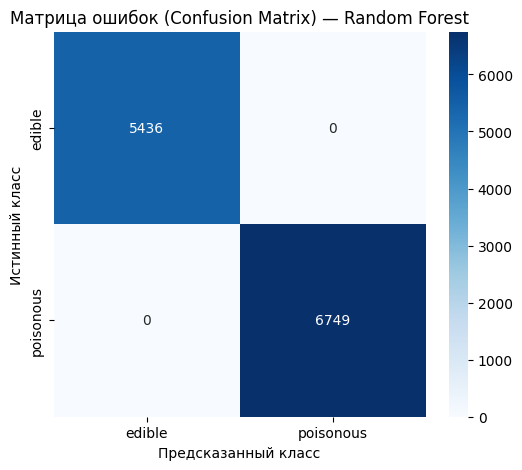

In [18]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Финальная модель — Random Forest
final_model = best_rf   # или best_gb, если хочешь анализировать её

y_pred_final = final_model.predict(X_test)
y_pred_proba_final = final_model.predict_proba(X_test)[:, 1]

print("=== Финальная модель: Random Forest ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred_final):.6f}")
print(f"F1-score: {f1_score(y_test, y_pred_final):.6f}")
print(f"ROC-AUC:  {roc_auc_score(y_test, y_pred_proba_final):.6f}")

# Подробный отчёт по классам
print("\nClassification Report:")
print(classification_report(y_test, y_pred_final, 
                            target_names=['edible (e)', 'poisonous (p)']))

# Матрица ошибок
cm = confusion_matrix(y_test, y_pred_final)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['edible', 'poisonous'], 
            yticklabels=['edible', 'poisonous'])
plt.ylabel('Истинный класс')
plt.xlabel('Предсказанный класс')
plt.title('Матрица ошибок (Confusion Matrix) — Random Forest')
plt.show()

## Анализ ошибок

- Типы ошибок в финальной модели
Random Forest допустил 0 ошибок на тестовой выборке (12 185 объектов). Это означает, что модель идеально разделила съедобные и ядовитые грибы в тестовом наборе.
- Сравнение с baseline
  - Исходное одиночное дерево допустило 5 ошибок (в основном FP и FN в равной пропорции).
  - После удаления шумных признаков одиночное дерево стало делать больше ошибок (20) — это признак снижения переобучения.
  - Ансамбли (особенно Random Forest) вернули идеальное качество, но уже на более чистых и обобщающих правилах.
- Влияние дисбаланса классов
Классы слегка несбалансированы (55.5% poisonous, 44.5% edible). Однако высокие метрики по обоим классам показывают, что дисбаланс не повлиял существенно. Корректировка class_weight или порога не требуется.

=== Топ-10 наиболее важных признаков (permutation importance) ===
 1. cat_clean__cap-color_n              — 0.0701
 2. cat_clean__cap-shape_s              — 0.0407
 3. cat_clean__cap-shape_x              — 0.0234
 4. cat_clean__cap-color_b              — 0.0181
 5. cat_clean__cap-shape_c              — 0.0078
 6. cat_clean__cap-shape_f              — 0.0075
 7. cat_clean__cap-color_g              — 0.0075
 8. cat_clean__cap-shape_p              — 0.0053
 9. cat_clean__cap-color_e              — 0.0030
10. cat_clean__cap-shape_o              — 0.0023


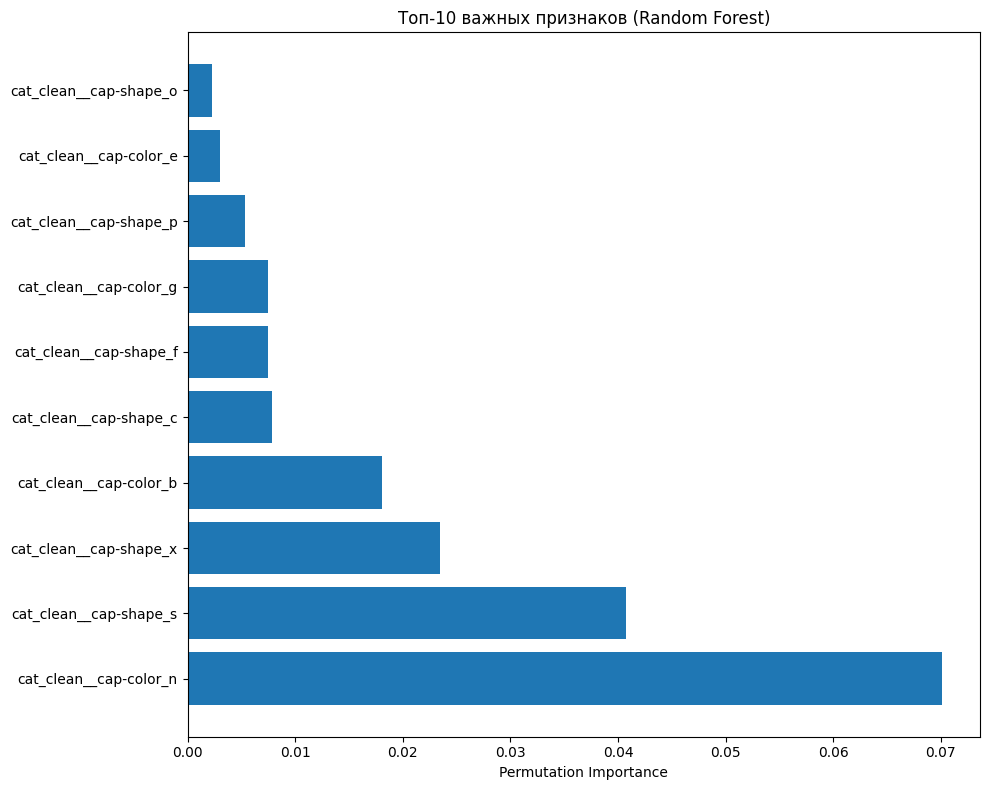

In [19]:
from sklearn.inspection import permutation_importance
import numpy as np

# Получаем имена признаков после препроцессинга
feature_names = final_model.named_steps['preprocessor'].get_feature_names_out()

# Built-in importance (Gini importance)
importances_gini = final_model.named_steps['classifier'].feature_importances_

# Permutation importance (более надёжный)
perm_importance = permutation_importance(final_model, X_test, y_test, 
                                         n_repeats=10, random_state=42, n_jobs=-1)

# Сортируем по permutation
indices = np.argsort(perm_importance.importances_mean)[::-1]

print("=== Топ-10 наиболее важных признаков (permutation importance) ===")
for i in range(10):
    print(f"{i+1:2}. {feature_names[indices[i]]:35} — {perm_importance.importances_mean[indices[i]]:.4f}")

# Визуализация
plt.figure(figsize=(10, 8))
plt.barh(range(10, 0, -1), perm_importance.importances_mean[indices[:10]])
plt.yticks(range(10, 0, -1), [feature_names[i] for i in indices[:10]])
plt.xlabel('Permutation Importance')
plt.title('Топ-10 важных признаков (Random Forest)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

выводы
бустинг хуже случайного леса
перестановка признаков против важности